In [54]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [55]:
kplus_Calbindin = 75 # μm^-1s^-1
kplus_EGTA = 1.5 # μm^-1s^-1
kplus_BAPTA = 600 # μm^-1s^-1
# B_conc_infty = 2 # 2 - 350 μM
Ca2_conc_infty = 0.1 # μM
R = 8.31 # J/(mol * k)
T = 300 # K
delta = 0.0733
f_c = 0.01
f_m = 0.0003
K_1 = 6 # μM
K_2 = 0.38 # μM
k_X = 0.008 # s^-1
L = 50
p_1 = 0.1 # mV^-1
p_2 = 0.016 # mV^-1
p_3 = 0.05 # mV^-1
V_MCU = 0.0006 # μMs^-1
V_NCX = 0.35 # 0.35 μMs^-1
z_Ca = 2
F = 96485 # Clmol
Na2_conc_out = 1400 # mM
Na2_conc_in = 20 # mM
P_Ca = 9.105 * (10**-11)
V_M = -0.07 # V
V_neuron = 523.6 # μm^3
D_leak = 0.11 # s^-1
D_chan = 6 # s^-1
Pmax_R = 0.9 # μMs^-1
K = 0.1 # μM
C_1 = 0.182 # μM
C_p = 1.8 # μM mV^-1

In [169]:
def dParams(t, C_vec):
    C_cyto = C_vec[0]
    C_ER = C_vec[1]
    C_mito = C_vec[2]
    Mito_membrane_voltage = C_vec[3]

    
    J_MCU = V_MCU * (C_cyto/K_1)*np.power(1+C_cyto/K_1,3) / ( np.power(1+C_cyto/K_1,3) + L/np.power(1+C_cyto/K_2,2.3) ) * np.exp(p_1*Mito_membrane_voltage)
    J_NCX = V_NCX * C_mito / C_cyto * np.exp(p_2*Mito_membrane_voltage)
    J_X = k_X * (C_cyto - C_mito) * np.exp(p_3*Mito_membrane_voltage)
    
    J = J_MCU + J_X - J_NCX
    C_0 = C_1 * C_ER + C_cyto

    dC_ER = Pmax_R * (C_cyto**2 / (C_cyto**2 + K**2))
    
    dC_cyto = (
        (1+C_1)*(D_leak + p_1 * D_chan) * (C_0 / (1+C_1) - C_cyto)
        - dC_ER
        # - total_association_rate * B_conc_infty * (C_cyto-Ca2_conc_infty)
        - delta * J
    )
    # + advection/diffusion terms

    dC_mito = f_m * J

    #dMito_membrane_voltage = -(J_NCX + 2*J_MCU + 2*J_X) / C_p
    dMito_membrane_voltage = 0
    return np.array([dC_cyto, dC_ER, dC_mito, dMito_membrane_voltage])

In [170]:
# initial conditions / parameters
C_vec_0 = np.array([0.1, 0.6, 0.3, -0.04])
B_conc_infty = 2 # 2 - 350 μM
total_association_rate = kplus_Calbindin + kplus_EGTA + kplus_BAPTA

In [177]:
# integrate
t_span = [0,8]
dt = 0.01
t_eval = np.arange(t_span[0],t_span[1],dt)
sol = solve_ivp(dParams, t_span, C_vec_0, t_eval=t_eval)

[ 0.1   0.6   0.3  -0.04]
-0.30835722151423517 0.06461 -0.45 0.07703277848576481
[ 0.09805732  0.60283504  0.29999801 -0.04      ]
-0.2973884548703638 0.06522737643452492 -0.4411730547656406 0.0785572234607519
[ 0.09599866  0.60583934  0.29999591 -0.04      ]
-0.2855124718831855 0.06588161150147466 -0.43163404822828644 0.08023996484362628
[ 0.09433149  0.60849089  0.29999367 -0.04      ]
-0.27567394655119526 0.0664396775004815 -0.4237699715202503 0.08165634746857353
[ 0.0860008   0.62175502  0.29998245 -0.04      ]
-0.223857555204397 0.06923016015768861 -0.38264378590971965 0.08955607054763401
[ 0.08426447  0.62432413  0.2999806  -0.04      ]
-0.21251377825931758 0.06978650970327883 -0.37369960459803014 0.09139931663543374
[ 0.08276027  0.62699559  0.29997789 -0.04      ]
-0.2024676355516642 0.07032608827940093 -0.3658519965145622 0.09305827268349702
[ 0.08341025  0.62646795  0.2999775  -0.04      ]
-0.20674667173254088 0.0701739152931561 -0.36925418849332914 0.09233360146763217
[ 0.07

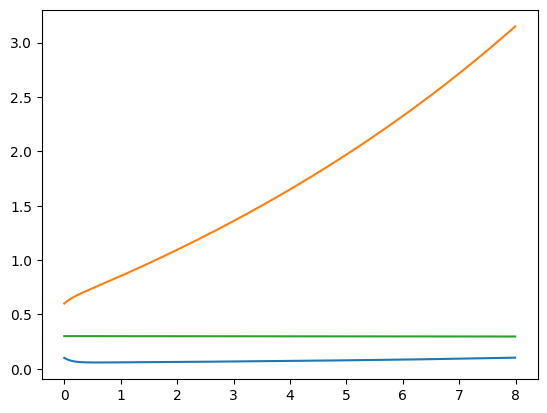

In [178]:
plt.plot(sol.t, sol.y[0])
plt.plot(sol.t, sol.y[1])
plt.plot(sol.t, sol.y[2])